# [Kaggle] Task 3: End-to-End PhoBERT-CRF
## Unified Model: ATE + ASC trong 1 model
BAT BUOC can GPU! Settings -> Accelerator -> GPU T4 x2


## 0. Setup


In [1]:
import subprocess, sys, os

# Install dependencies
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'underthesea', 'pytorch-crf', 'gensim', 'transformers', 'py_vncorenlp'])

# =====================================================
# THAY DOI TEN DATASET DUOI DAY CHO DUNG
# =====================================================
DATA_DATASET = "UIT-ViSD4SA"      # Dataset chua train/dev/test.jsonl
SRC_DATASET  = "absa-src"       # Dataset chua folder src/

IS_KAGGLE = os.path.exists('/kaggle/input')
if IS_KAGGLE:
    DATA_DIR = '/kaggle/input/datasets/danghoang1302/uit-visd4sa'
    SAVE_DIR = '/kaggle/working/results'
    PREP_DIR = '/kaggle/working/preprocessed'

    # Kaggle mount: /kaggle/input/absa-src/src/{asc,ate,e2e,utils}
    # Copy sang working vi Kaggle input la read-only (relative imports can write cache)
    SRC_INPUT = '/kaggle/input/datasets/danghoang1302/absa-src'
    os.system(f'cp -r {SRC_INPUT}/src /kaggle/working/src')
    sys.path.insert(0, '/kaggle/working')

    print(f"KAGGLE | Data: {DATA_DIR}")
    print(f"KAGGLE | Src copied to: /kaggle/working/src/")
else:
    sys.path.insert(0, os.path.abspath(".."))
    DATA_DIR = os.path.join("..", "..", "data")
    SAVE_DIR = os.path.join("..", "..", "results")
    PREP_DIR = os.path.join("..", "..", "preprocessed")
    print(f"LOCAL mode")

# Verify
for fn in ['train.jsonl', 'dev.jsonl', 'test.jsonl']:
    assert os.path.exists(os.path.join(DATA_DIR, fn)), f"MISSING: {fn}"
print("All data files OK!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.0 MB/s eta 0:00:00
KAGGLE | Data: /kaggle/input/datasets/danghoang1302/uit-visd4sa
KAGGLE | Src copied to: /kaggle/working/src/
All data files OK!


## 1. Imports & Load


In [2]:
import torch, numpy as np, pandas as pd
from torch.utils.data import DataLoader
from IPython.display import display

from src.utils.preprocess import load_raw_data
from src.e2e.e2e_dataset import E2EDataset, BIO_TAGS, TAG2ID, NUM_TAGS
from src.e2e.e2e_model import E2EPhoBertCRF
from src.utils.engine import train_e2e_model, predict_e2e
from src.utils.metrics import bio_tags_to_spans, evaluate_spans_f1, token_accuracy
from src.utils.visualization import plot_training_curves

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42)
print(f"Device: {device}")

train_items = load_raw_data(os.path.join(DATA_DIR, "train.jsonl"))
dev_items = load_raw_data(os.path.join(DATA_DIR, "dev.jsonl"))
test_items = load_raw_data(os.path.join(DATA_DIR, "test.jsonl"))
print(f"Train: {len(train_items)} | Dev: {len(dev_items)} | Test: {len(test_items)}")


--2026-04-24 06:24:13--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27412703 (26M) [application/octet-stream]
Saving to: ‘VnCoreNLP-1.2.jar’

     0K .......... .......... .......... .......... ..........  0% 4.22M 6s
    50K .......... .......... .......... .......... ..........  0% 5.14M 6s
   100K .......... .......... .......... .......... ..........  0% 22.7M 4s
   150K .......... .......... .......... .......... ..........  0% 27.4M 3s
   200K .......... .......... .......... .......... ..........  0% 7.56M 3s
   250K .......... .......... .......... .......... ..........  1% 91.5M 3s
   300K .......... .......... .......... .......... ..........  1% 25.1M 3s
   350K ..

2026-04-24 06:24:18 INFO  WordSegmenter:24 - Loading Word Segmentation model
Device: cuda
Train: 7785 | Dev: 1112 | Test: 2225


## 2. E2E Dataset (PhoBERT Tokenizer)


In [ ]:
MAX_LEN = 256; BATCH_SIZE = 16

print("Tokenizing with PhoBERT...")
train_ds = E2EDataset(train_items, max_len=MAX_LEN, is_train=True)
dev_ds = E2EDataset(dev_items, max_len=MAX_LEN)
test_ds = E2EDataset(test_items, max_len=MAX_LEN)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_ds, BATCH_SIZE)
test_loader = DataLoader(test_ds, BATCH_SIZE)
print("Ready!")


## 3. Train PhoBERT-CRF


In [ ]:
LR_OPTIONS = [2e-5, 5e-5]
all_models, all_histories, all_results = {}, {}, []

for lr in LR_OPTIONS:
    name = f"PhoBERT-CRF_lr{lr}"
    model = E2EPhoBertCRF(num_unified_tags=NUM_TAGS, dropout=0.1).to(device)
    model, history = train_e2e_model(model, train_loader, dev_loader, device,
        lr=lr, epochs=15, patience=5, model_name=name)
    all_models[name] = model; all_histories[name] = history


## 4. Evaluate & Compare


,Model,Span_F1,Token_Acc
0,PhoBERT-CRF_lr2e-05,0.597100,0.758700
1,PhoBERT-CRF_lr5e-05,0.562100,0.748000


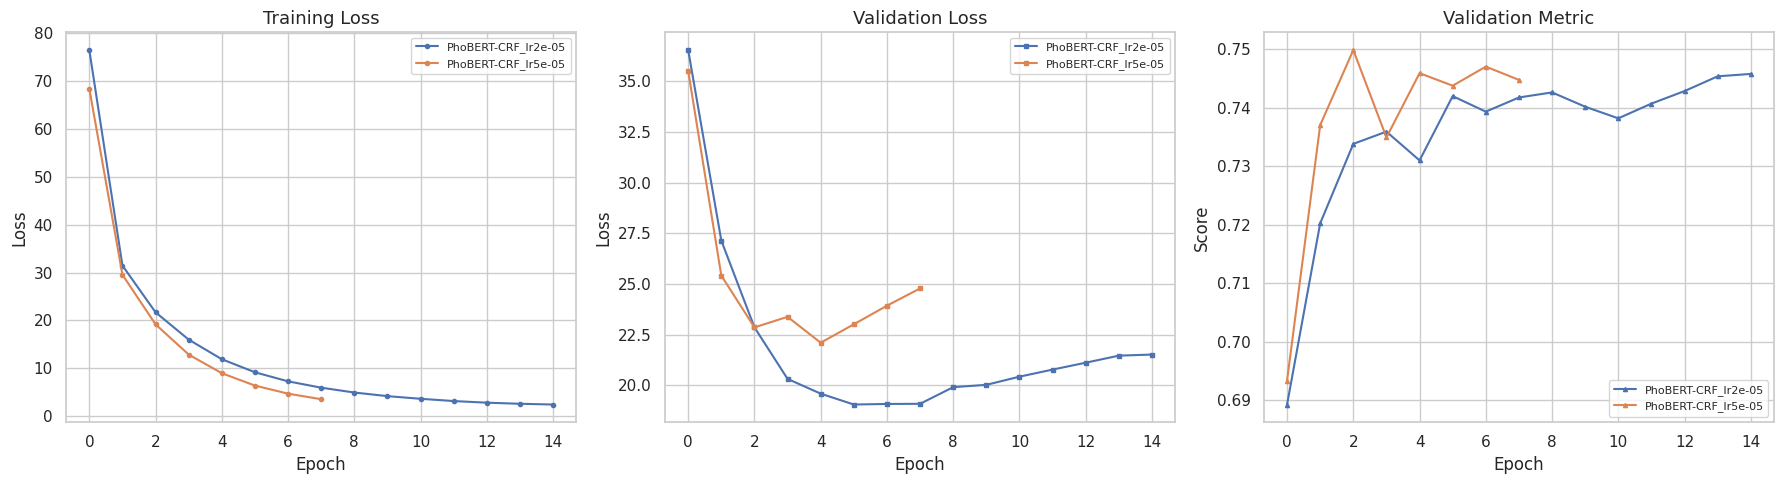

Chua co ket qua baseline de so sanh.


In [5]:
for name, model in all_models.items():
    res = predict_e2e(model, test_loader, device)
    ps = [bio_tags_to_spans(pt, BIO_TAGS, l) for pt, l in zip(res["pred_tags"], res["lengths"])]
    ts = [bio_tags_to_spans(tt, BIO_TAGS, l) for tt, l in zip(res["true_tags"], res["lengths"])]
    sf = evaluate_spans_f1(ps, ts)
    ta = token_accuracy(res["pred_tags"], res["true_tags"])
    all_results.append({"Model": name, "Span_F1": round(sf["f1"],4), "Token_Acc": round(ta,4)})

e2e_df = pd.DataFrame(all_results)
display(e2e_df.style.highlight_max(subset=["Span_F1"], color="lightgreen"))
plot_training_curves(all_histories)

# So sanh voi Pipeline
try:
    ate_df = pd.read_csv(os.path.join(SAVE_DIR, "ate", "ate_results.csv"))
    print("\n=== SO SANH ===")
    print("ATE Baselines:"); display(ate_df)
    print("E2E PhoBERT:"); display(e2e_df)
except: print("Chua co ket qua baseline de so sanh.")


## 5. Save


In [6]:
E2E_DIR = os.path.join(SAVE_DIR, "e2e"); os.makedirs(E2E_DIR, exist_ok=True)
e2e_df.to_csv(os.path.join(E2E_DIR, "e2e_results.csv"), index=False)
best_name = e2e_df.loc[e2e_df["Span_F1"].idxmax(), "Model"]
torch.save(all_models[best_name].state_dict(), os.path.join(E2E_DIR, "best_e2e_phobert.pt"))
print(f"Best: {best_name} (F1={e2e_df['Span_F1'].max():.4f}) -> Saved!")


Best: PhoBERT-CRF_lr2e-05 (F1=0.5971) -> Saved!
